### SentraGrade — Supervised CNN Baseline

Trains an ImageNet-pretrained ResNet50 on the 5 in-distribution classes for
each of the 6 leave-one-class-out folds, then:
- computes OOD scores (energy, MSP, prototype distance) from the trained
  checkpoints,
- evaluates them with AUROC / FPR@95 across all 6 folds,
- runs Grad-CAM for explainability,
- and shows concrete input → output examples (image in, decision + heatmap
  out) so you can demo this directly.

In [1]:
!nvidia-smi 2>/dev/null || echo "No CUDA GPU visible (fine if you're running this on Mac)"

No CUDA GPU visible (fine if you're running this on Mac)


In [2]:
import json, os, time, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
from PIL import Image
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print(f"Using device: {DEVICE}")

Using device: mps


In [ ]:

candidates = [
    Path("~/sentragrade_data").expanduser(),
    Path.cwd(),
    Path.cwd().parent / "sentragrade_data",
]
DATA_ROOT = next(
    (p for p in candidates if (p / "folds").exists() or (p / "manifest_full.csv").exists()),
    Path("~/sentragrade_data").expanduser(),
)
print(f"Using local dataset at: {DATA_ROOT}")

FOLD_DIR = DATA_ROOT / "folds"
assert FOLD_DIR.exists(), (
    f"Fold manifests not found at {FOLD_DIR}. "
    "Expected a folder like ~/sentragrade_data created by preprocessing.py."
)
fold_summary = pd.read_csv(FOLD_DIR / "fold_summary.csv")
CLASSES_ALL = sorted(set(fold_summary["held_out_class"]))
print(f"DATA_ROOT = {DATA_ROOT}")

Using local dataset at: /Users/riteeshtm/sentragrade_data
DATA_ROOT = /Users/riteeshtm/sentragrade_data


## 2. Dataset and transforms

In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


def denormalize(img_tensor):
    """Undo ImageNet normalization for display. Expects a [3,H,W] tensor."""
    mean = torch.tensor(IMAGENET_MEAN, device=img_tensor.device).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD, device=img_tensor.device).view(3, 1, 1)
    return (img_tensor * std + mean).clamp(0, 1)


class ProduceDataset(Dataset):
    """Reads a fold manifest CSV. label is -1 for the OOD (held-out class)
    split, since those images have no valid label among the 5 known classes."""

    def __init__(self, csv_path, label_map, transform, data_root):
        self.df = pd.read_csv(csv_path)
        self.label_map = label_map
        self.transform = transform
        self.data_root = Path(data_root)

    def __len__(self):
        return len(self.df)

    def _resolve_path(self, row):
        return self.data_root / "resized" / row.class_name / row.filename

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self._resolve_path(row)
        img = Image.open(img_path).convert("RGB")
        img = self.transform(img)
        label = self.label_map.get(row.class_name, -1)
        return img, label, str(img_path)

## 3. Model — ResNet50, partial fine-tune, exposes both logits and pooled features

In [5]:
class ResNetClassifier(nn.Module):
    """Wraps torchvision resnet50. freeze_until controls how much of the
    backbone is frozen: 'layer2' (default) freezes conv1/bn1/layer1/layer2
    and fine-tunes layer3, layer4, fc. Returns (logits, 2048-d pooled
    features) — the features feed the prototype-distance OOD score, and
    layer4's activations are what Grad-CAM hooks into later."""

    def __init__(self, num_classes, freeze_until="layer2"):
        super().__init__()
        backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        self.stem = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool)
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4
        self.avgpool = backbone.avgpool
        self.fc = nn.Linear(backbone.fc.in_features, num_classes)

        freeze_order = ["stem", "layer1", "layer2", "layer3", "layer4"]
        freeze_idx = freeze_order.index(freeze_until)
        for name in freeze_order[: freeze_idx + 1]:
            for p in getattr(self, name).parameters():
                p.requires_grad = False

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        feats = torch.flatten(x, 1)
        logits = self.fc(feats)
        return logits, feats

    def trainable_param_groups(self, backbone_lr=1e-4, head_lr=1e-3):
        backbone_params = [p for n, p in self.named_parameters() if p.requires_grad and not n.startswith("fc")]
        head_params = [p for p in self.fc.parameters() if p.requires_grad]
        return [
            {"params": backbone_params, "lr": backbone_lr},
            {"params": head_params, "lr": head_lr},
        ]

## 4. Train one fold

In [6]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for imgs, labels, _ in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits, _ = model(imgs)
            loss = criterion(logits, labels)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct += (logits.argmax(1) == labels).sum().item()
            n += imgs.size(0)
    return total_loss / n, correct / n


@torch.no_grad()
def collect_logits_features(model, loader):
    model.eval()
    all_logits, all_feats, all_labels, all_paths = [], [], [], []
    for imgs, labels, paths in loader:
        imgs = imgs.to(DEVICE)
        logits, feats = model(imgs)
        all_logits.append(logits.cpu())
        all_feats.append(feats.cpu())
        all_labels.append(labels)
        all_paths.extend(paths)
    return {
        "logits": torch.cat(all_logits),
        "features": torch.cat(all_feats),
        "labels": torch.cat(all_labels),
        "paths": all_paths,
    }


def train_one_fold(fold_idx, epochs=25, batch_size=32, patience=6, num_workers=0):
    # On macOS + Jupyter/Notebook, DataLoader with multiprocessing workers can
    # fail to pickle the custom Dataset class. Keep workers at 0 here unless you
    # run from a normal Python script with a proper __main__ guard.
    print(f"\n{'='*60}\nFold {fold_idx}\n{'='*60}")

    with open(FOLD_DIR / f"fold{fold_idx}_label_map.json") as f:
        label_map = json.load(f)
    num_classes = len(label_map)

    train_ds = ProduceDataset(FOLD_DIR / f"fold{fold_idx}_train.csv", label_map, train_tf, DATA_ROOT)
    val_ds = ProduceDataset(FOLD_DIR / f"fold{fold_idx}_val.csv", label_map, eval_tf, DATA_ROOT)
    ood_ds = ProduceDataset(FOLD_DIR / f"fold{fold_idx}_ood.csv", label_map, eval_tf, DATA_ROOT)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    ood_loader = DataLoader(ood_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    train_labels = train_ds.df["class_name"].map(label_map).values
    class_weights = compute_class_weight("balanced", classes=np.arange(num_classes), y=train_labels)
    class_weights = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    model = ResNetClassifier(num_classes, freeze_until="layer2").to(DEVICE)
    optimizer = torch.optim.AdamW(model.trainable_param_groups(), weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_acc, best_state, epochs_no_improve = 0.0, None, 0
    for epoch in range(epochs):
        t0 = time.time()
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)
        scheduler.step()
        dt = time.time() - t0
        print(f"epoch {epoch+1:2d}/{epochs}  train_loss={train_loss:.3f} train_acc={train_acc:.3f}  "
              f"val_loss={val_loss:.3f} val_acc={val_acc:.3f}  ({dt:.1f}s)")

        if val_acc > best_val_acc:
            best_val_acc, best_state, epochs_no_improve = val_acc, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1} (best val_acc={best_val_acc:.3f})")
                break

    model.load_state_dict(best_state)

    val_results = collect_logits_features(model, val_loader)
    ood_results = collect_logits_features(model, ood_loader)

    ckpt_dir = DATA_ROOT / "checkpoints" / "supervised_cnn"
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "fold_idx": fold_idx,  # see folds/fold_summary.csv for the held-out class name
            "label_map": label_map,
            "model_state_dict": best_state,
            "best_val_acc": best_val_acc,
            "val": val_results,
            "ood": ood_results,
        },
        ckpt_dir / f"fold{fold_idx}.pt",
    )
    print(f"Saved checkpoint + logits/features -> {ckpt_dir / f'fold{fold_idx}.pt'}")
    return best_val_acc

## 5. Run all 6 folds

This is the expensive part. If a Colab session drops mid-way, just re-run
this cell — folds whose checkpoint file already exists are skipped, so you
only pay for the folds that haven't finished.

In [7]:
CKPT_DIR = DATA_ROOT / "checkpoints" / "supervised_cnn"
results = []

for fold_idx in fold_summary["fold"]:
    ckpt_path = CKPT_DIR / f"fold{fold_idx}.pt"
    if ckpt_path.exists():
        print(f"Fold {fold_idx} already done, skipping (delete {ckpt_path} to redo).")
        saved = torch.load(ckpt_path, map_location="cpu", weights_only=False)
        val_acc = saved["best_val_acc"]
    else:
        val_acc = train_one_fold(fold_idx)
    held_out = fold_summary.loc[fold_summary.fold == fold_idx, "held_out_class"].item()
    results.append({"fold": fold_idx, "held_out_class": held_out, "best_val_acc": val_acc})

results_df = pd.DataFrame(results)
print("\n=== Supervised CNN baseline — per-fold in-distribution val accuracy ===")
print(results_df)
results_df.to_csv(CKPT_DIR / "summary.csv", index=False)

Fold 0 already done, skipping (delete /Users/riteeshtm/sentragrade_data/checkpoints/supervised_cnn/fold0.pt to redo).
Fold 1 already done, skipping (delete /Users/riteeshtm/sentragrade_data/checkpoints/supervised_cnn/fold1.pt to redo).
Fold 2 already done, skipping (delete /Users/riteeshtm/sentragrade_data/checkpoints/supervised_cnn/fold2.pt to redo).
Fold 3 already done, skipping (delete /Users/riteeshtm/sentragrade_data/checkpoints/supervised_cnn/fold3.pt to redo).
Fold 4 already done, skipping (delete /Users/riteeshtm/sentragrade_data/checkpoints/supervised_cnn/fold4.pt to redo).
Fold 5 already done, skipping (delete /Users/riteeshtm/sentragrade_data/checkpoints/supervised_cnn/fold5.pt to redo).

=== Supervised CNN baseline — per-fold in-distribution val accuracy ===
   fold     held_out_class  best_val_acc
0     0             Banana           1.0
1     1             Carrot           1.0
2     2              Guava           1.0
3     3  Indian_Gooseberry           1.0
4     4       

## 6. OOD scoring — energy, MSP, prototype distance

Each checkpoint already has logits and 2048-d features cached for its val
(known) and ood (truly unseen) sets — that covers energy and MSP directly.
Prototype distance additionally needs a per-class prototype (mean embedding
of each known class), which requires running the *training* set through the
model once — that wasn't cached during training, so this section reloads
each fold's model and does that one extra pass.

All three scores below are oriented the same way: **higher = more
OOD-like**, so they can be compared and thresholded consistently.
- **MSP**: `-max(softmax(logits))` — low confidence in any known class → high score.
- **Energy**: `-logsumexp(logits)` — the standard energy-based OOD score (Liu et al., 2020).
- **Prototype distance**: Euclidean distance from the sample's feature vector to its nearest known-class prototype.

In [8]:
def load_model_from_checkpoint(fold_idx):
    ckpt_path = CKPT_DIR / f"fold{fold_idx}.pt"
    # weights_only=False: this checkpoint stores plain Python objects (label
    # map, file path strings) alongside tensors, not just a state_dict, so
    # PyTorch's newer weights_only=True default (safe-guard against
    # arbitrary pickle content) would refuse to load it.
    ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    label_map = ckpt["label_map"]
    model = ResNetClassifier(len(label_map)).to(DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    return model, ckpt, label_map


def compute_class_prototypes(model, fold_idx, label_map):
    """Mean feature vector per known class, computed from that fold's
    training set (not train-time augmented — uses eval_tf for stability)."""
    train_ds = ProduceDataset(FOLD_DIR / f"fold{fold_idx}_train.csv", label_map, eval_tf, DATA_ROOT)
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=False, num_workers=0)
    result = collect_logits_features(model, train_loader)
    feats, labels = result["features"], result["labels"]
    num_classes = len(label_map)
    prototypes = torch.stack([feats[labels == c].mean(dim=0) for c in range(num_classes)])
    return prototypes


def compute_ood_scores(logits, features, prototypes):
    probs = torch.softmax(logits, dim=1)
    msp_score = (-probs.max(dim=1).values).numpy()

    energy_score = (-torch.logsumexp(logits, dim=1)).numpy()

    dists = torch.cdist(features, prototypes)
    proto_score = dists.min(dim=1).values.numpy()

    return {"msp": msp_score, "energy": energy_score, "proto": proto_score}


# Reload every fold's model once, compute prototypes + scores, and keep
# everything in memory (fold_cache) so Sections 7-9 don't need to redo this.
fold_cache = {}
for fold_idx in fold_summary["fold"]:
    print(f"Scoring fold {fold_idx}...")
    model, ckpt, label_map = load_model_from_checkpoint(fold_idx)
    prototypes = compute_class_prototypes(model, fold_idx, label_map)

    val_scores = compute_ood_scores(ckpt["val"]["logits"], ckpt["val"]["features"], prototypes)
    ood_scores = compute_ood_scores(ckpt["ood"]["logits"], ckpt["ood"]["features"], prototypes)

    fold_cache[fold_idx] = {
        "model": model,
        "ckpt": ckpt,
        "label_map": label_map,
        "inv_label_map": {v: k for k, v in label_map.items()},
        "prototypes": prototypes,
        "val_scores": val_scores,
        "ood_scores": ood_scores,
    }
print("Done scoring all folds.")

Scoring fold 0...
Scoring fold 1...
Scoring fold 2...
Scoring fold 3...
Scoring fold 4...
Scoring fold 5...
Done scoring all folds.


## 7. Evaluation — AUROC and FPR@95

For each fold and each scoring method: val (known) samples are the negative
class (label 0), the true held-out class's samples are the positive class
(label 1, "is OOD"), and the score decides ranking. AUROC summarizes
separability across all thresholds; FPR@95 is the standard operating-point
metric — at the threshold where 95% of true OOD samples are caught, what
fraction of legitimate known produce gets wrongly flagged?

In [9]:
def fpr_at_tpr(labels, scores, tpr_target=0.95):
    fpr, tpr, _ = roc_curve(labels, scores)
    idx = np.searchsorted(tpr, tpr_target)
    idx = min(idx, len(fpr) - 1)
    return fpr[idx]


eval_rows = []
for fold_idx, fc in fold_cache.items():
    held_out_class = fold_summary.loc[fold_summary.fold == fold_idx, "held_out_class"].item()
    n_val = len(fc["ckpt"]["val"]["labels"])
    n_ood = len(fc["ckpt"]["ood"]["labels"])
    labels = np.concatenate([np.zeros(n_val), np.ones(n_ood)])
    for method in ["msp", "energy", "proto"]:
        scores = np.concatenate([fc["val_scores"][method], fc["ood_scores"][method]])
        auroc = roc_auc_score(labels, scores)
        fpr95 = fpr_at_tpr(labels, scores)
        eval_rows.append({
            "fold": fold_idx, "held_out_class": held_out_class, "method": method,
            "AUROC": auroc, "FPR@95": fpr95, "n_val": n_val, "n_ood": n_ood,
        })

eval_df = pd.DataFrame(eval_rows)
print("=== Per-fold results ===")
print(eval_df.to_string(index=False))

summary = eval_df.groupby("method")[["AUROC", "FPR@95"]].agg(["mean", "std"])
print("\n=== Aggregated across all 6 folds (mean \u00b1 std) ===")
print(summary)

eval_df.to_csv(CKPT_DIR / "ood_eval_per_fold.csv", index=False)
summary.to_csv(CKPT_DIR / "ood_eval_summary.csv")
print(f"\nSaved -> {CKPT_DIR / 'ood_eval_per_fold.csv'} and ood_eval_summary.csv")

=== Per-fold results ===
 fold    held_out_class method    AUROC   FPR@95  n_val  n_ood
    0            Banana    msp 0.997883 0.009643   1037    323
    0            Banana energy 0.999654 0.001929   1037    323
    0            Banana  proto 0.999421 0.002893   1037    323
    1            Carrot    msp 0.998926 0.004822   1037    458
    1            Carrot energy 0.999699 0.001929   1037    458
    1            Carrot  proto 0.997831 0.008679   1037    458
    2             Guava    msp 0.981095 0.075217   1037    510
    2             Guava energy 0.990533 0.029894   1037    510
    2             Guava  proto 0.974718 0.061716   1037    510
    3 Indian_Gooseberry    msp 0.924954 0.445882    850   1411
    3 Indian_Gooseberry energy 0.982694 0.082353    850   1411
    3 Indian_Gooseberry  proto 0.958349 0.105882    850   1411
    4             Mango    msp 0.959359 0.181214   1054    392
    4             Mango energy 0.969523 0.174573   1054    392
    4             Mango  proto

## 8. Grad-CAM

Hooks into `layer4` (the last conv block) to show which part of the image
drove the model's decision — this is what makes the rejection
"explainable" rather than a bare number, per the problem statement.

In [10]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, output):
        self.activations = output

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, x, class_idx=None):
        """x: [B,3,224,224] on DEVICE. Returns a [B,224,224] heatmap in
        [0,1], and the logits (so callers don't need a second forward pass)."""
        self.model.zero_grad()
        logits, _ = self.model(x)
        if class_idx is None:
            class_idx = logits.argmax(dim=1)
        score = logits[torch.arange(logits.size(0), device=x.device), class_idx].sum()
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = torch.relu((weights * self.activations).sum(dim=1))
        cam = F.interpolate(cam.unsqueeze(1), size=x.shape[-2:], mode="bilinear", align_corners=False).squeeze(1)
        cam_min = cam.amin(dim=(1, 2), keepdim=True)
        cam_max = cam.amax(dim=(1, 2), keepdim=True)
        cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)
        return cam.detach().cpu(), logits.detach()


def make_gradcam_for_fold(fold_idx):
    model = fold_cache[fold_idx]["model"]
    return GradCAM(model, model.layer4[-1])

## 9. Input → output demo examples

This is the part to actually show your teacher: real images in, the
model's decision (and *why*, via Grad-CAM) out.

Pick a fold to demo (`DEMO_FOLD`). The threshold below is set at the 95th
percentile of that fold's in-distribution energy scores — i.e. it accepts
95% of genuinely known produce and flags the rest as a false-reject budget,
then the same threshold is applied to the true OOD (held-out class) images.
This is one reasonable operating point, not the only one — your report's
"decision layer" section should discuss this as a tunable choice (see
Section 7 for how AUROC summarizes performance across *all* thresholds at
once).

Demo fold 0 (held out: Banana), method=energy, threshold=-5.2152


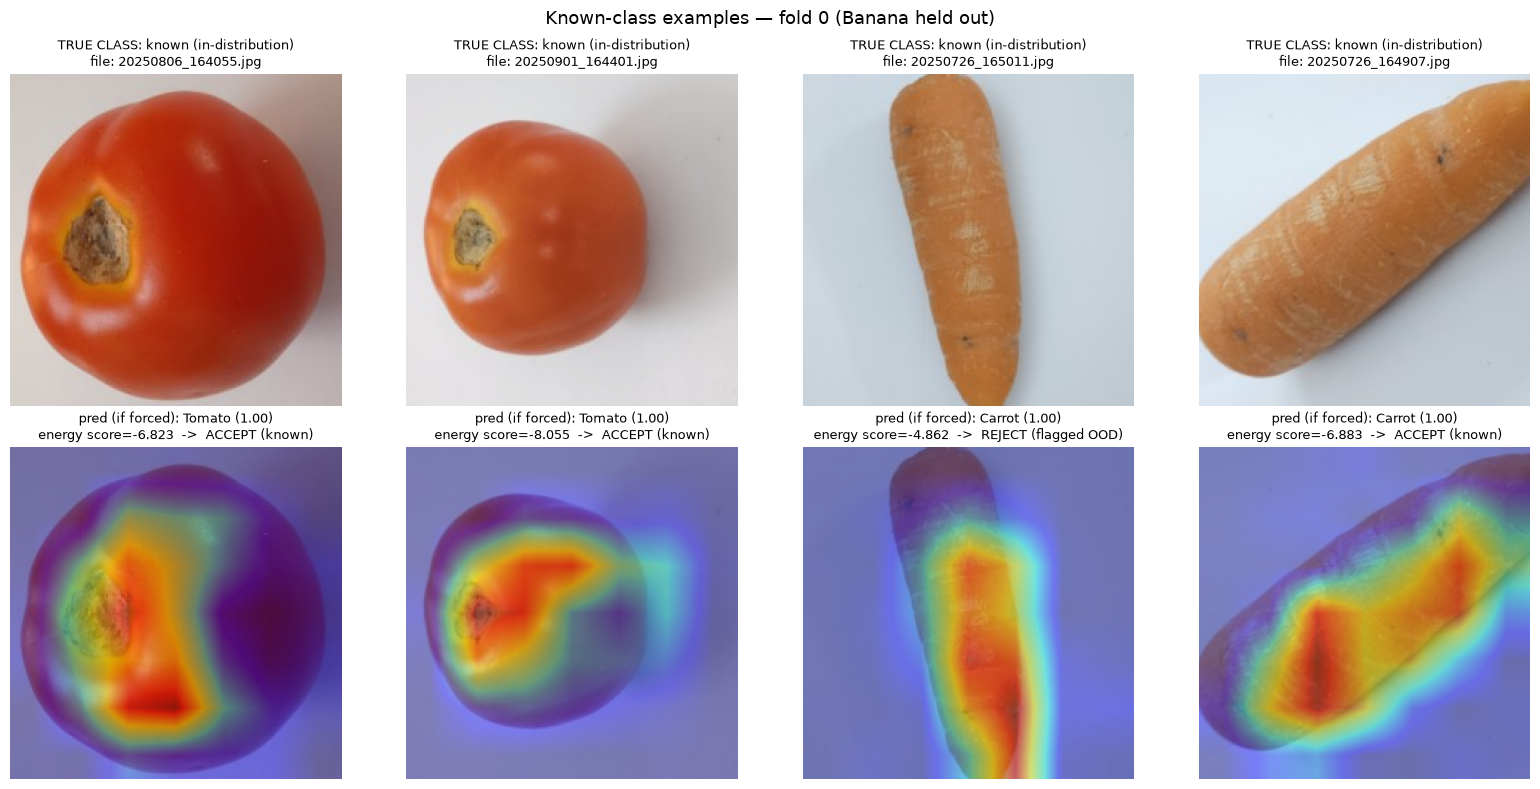

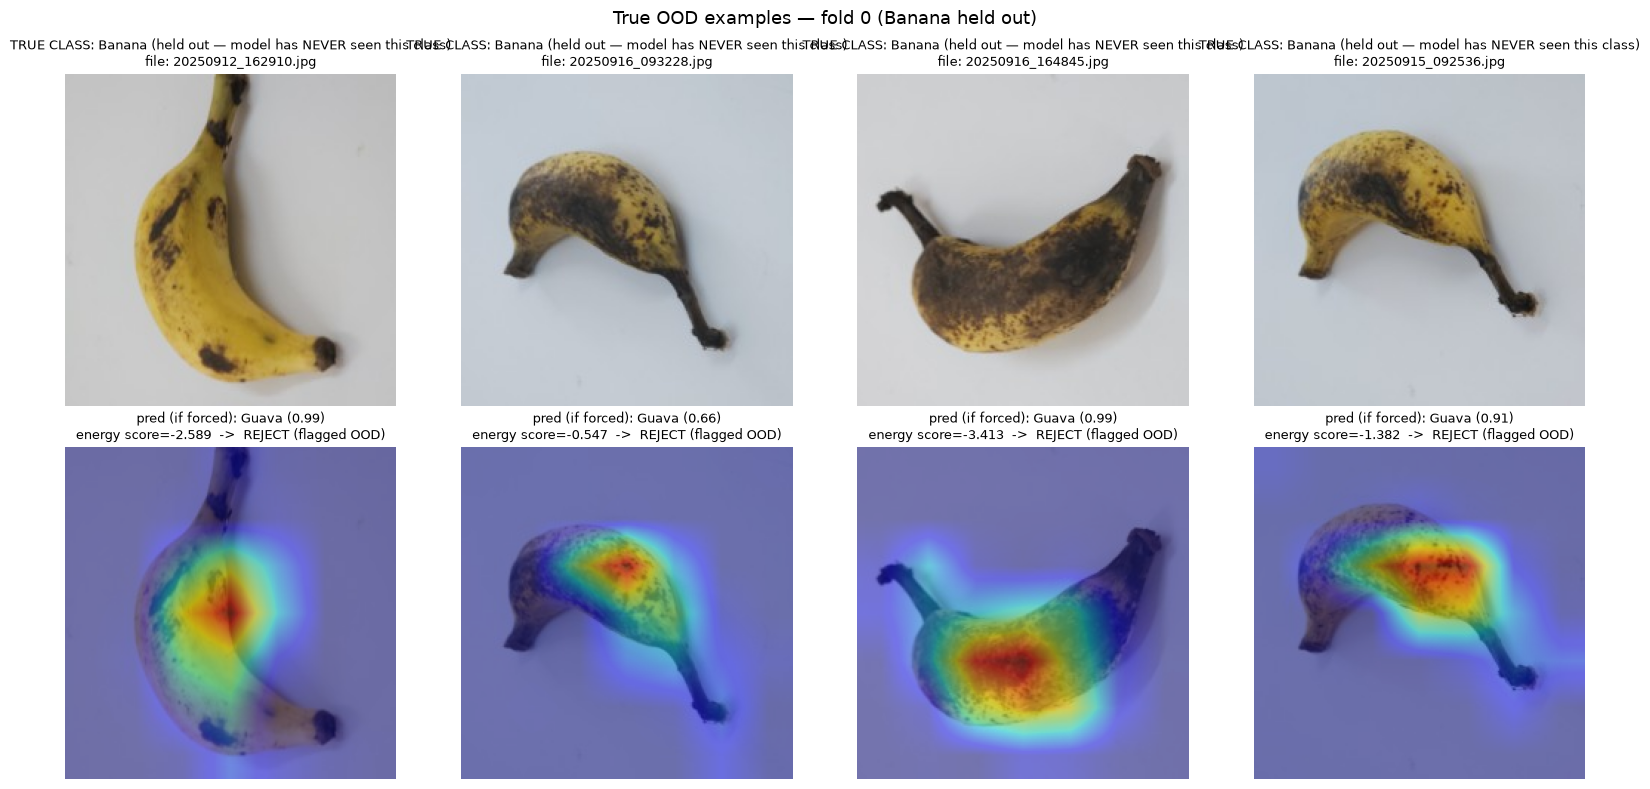


At this threshold: 323/323 true Banana images (100.0%) were correctly flagged as OOD.
The 'pred (if forced)' label on the OOD row shows what a standard closed-set
classifier would have wrongly called it, had nothing caught it — this is
exactly the failure mode from the problem statement.


In [11]:
DEMO_FOLD = 0        # change this to demo a different held-out class
DEMO_METHOD = "energy"  # "energy" is generally the strongest OOD score in the literature
N_ID_EXAMPLES = 4
N_OOD_EXAMPLES = 4

fc = fold_cache[DEMO_FOLD]
held_out_class = fold_summary.loc[fold_summary.fold == DEMO_FOLD, "held_out_class"].item()
threshold = float(np.percentile(fc["val_scores"][DEMO_METHOD], 95))
print(f"Demo fold {DEMO_FOLD} (held out: {held_out_class}), method={DEMO_METHOD}, threshold={threshold:.4f}")

gradcam = make_gradcam_for_fold(DEMO_FOLD)
model = fc["model"]


def load_and_transform(path):
    img = Image.open(path).convert("RGB")
    return eval_tf(img)


def show_examples(paths, true_labels_desc, scores, logits, threshold, title):
    n = len(paths)
    fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))
    if n == 1:
        axes = axes.reshape(2, 1)
    for i, path in enumerate(paths):
        img_t = load_and_transform(path).unsqueeze(0).to(DEVICE)
        class_idx = int(logits[i].argmax())
        pred_class = fc["inv_label_map"][class_idx]
        confidence = float(torch.softmax(logits[i], dim=0).max())
        score = float(scores[i])
        decision = "REJECT (flagged OOD)" if score > threshold else "ACCEPT (known)"

        cam, _ = gradcam(img_t, class_idx=torch.tensor([class_idx], device=DEVICE))
        disp_img = denormalize(img_t[0].cpu()).permute(1, 2, 0).numpy()

        axes[0, i].imshow(disp_img)
        axes[0, i].axis("off")
        axes[0, i].set_title(
            f"{true_labels_desc}\nfile: {Path(path).name}",
            fontsize=9,
        )

        axes[1, i].imshow(disp_img)
        axes[1, i].imshow(cam[0], cmap="jet", alpha=0.45)
        axes[1, i].axis("off")
        axes[1, i].set_title(
            f"pred (if forced): {pred_class} ({confidence:.2f})\n"
            f"{DEMO_METHOD} score={score:.3f}  ->  {decision}",
            fontsize=9,
        )
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


# --- known-class (in-distribution) examples ---
val_paths = fc["ckpt"]["val"]["paths"]
val_logits = fc["ckpt"]["val"]["logits"]
val_labels = fc["ckpt"]["val"]["labels"]
val_scores_arr = fc["val_scores"][DEMO_METHOD]

id_idx = np.random.RandomState(0).choice(len(val_paths), size=min(N_ID_EXAMPLES, len(val_paths)), replace=False)
show_examples(
    [val_paths[i] for i in id_idx],
    "TRUE CLASS: known (in-distribution)",
    [val_scores_arr[i] for i in id_idx],
    [val_logits[i] for i in id_idx],
    threshold,
    f"Known-class examples — fold {DEMO_FOLD} ({held_out_class} held out)",
)

# --- true OOD (held-out class) examples ---
ood_paths = fc["ckpt"]["ood"]["paths"]
ood_logits = fc["ckpt"]["ood"]["logits"]
ood_scores_arr = fc["ood_scores"][DEMO_METHOD]

ood_idx = np.random.RandomState(0).choice(len(ood_paths), size=min(N_OOD_EXAMPLES, len(ood_paths)), replace=False)
show_examples(
    [ood_paths[i] for i in ood_idx],
    f"TRUE CLASS: {held_out_class} (held out — model has NEVER seen this class)",
    [ood_scores_arr[i] for i in ood_idx],
    [ood_logits[i] for i in ood_idx],
    threshold,
    f"True OOD examples — fold {DEMO_FOLD} ({held_out_class} held out)",
)

n_caught = int((ood_scores_arr > threshold).sum())
print(f"\nAt this threshold: {n_caught}/{len(ood_scores_arr)} true {held_out_class} images "
      f"({100*n_caught/len(ood_scores_arr):.1f}%) were correctly flagged as OOD.")
print("The 'pred (if forced)' label on the OOD row shows what a standard closed-set")
print("classifier would have wrongly called it, had nothing caught it — this is")
print("exactly the failure mode from the problem statement.")